<a href="https://colab.research.google.com/github/laramutair/Prediction-of-Product-Sales/blob/main/Prediction_of_Product_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Project Title: (sales prediction).
- Author: Lara Mutair

## Project Overview part1 & part2

**Part 1**

This is an overview of the steps you will need to complete for part one of the project. There are more detailed instructions for each section following the overview.

Create a GitHub Account

Set up a GitHub repository that will house your first portfolio project.

Add Markdown cells with your name and section headers to the notebook.

Add the Google Colab Notebook to your GitHub repository.

Submit the link to your GitHub repo!


**Part 2**

We will continue to work off of the GitHub repository you created last week for your first portfolio project. The goal of your portfolio projects are to have items to show potential employers that demonstrate your data science skills and competencies.

The first project will be a sales prediction for food items sold at various stores. The goal of this is to help the retailer understand the properties of products and outlets that play crucial roles in increasing sales.

For Part 2, your task is to use Pandas to load in the data and start exploring and cleaning it.

- Download the data using this link: [download the data](https://drive.google.com/file/d/1syH81TVrbBsdymLT_jl2JIf6IjPXtSQw/view).
- Insert code below the heading "Loading Data"
  - Use Pandas to read the sales prediction data set into Google Colab.
  - Use df.info() and df.head() methods to preview the first rows of your data and a summary of your DataFrame's columns.
- Insert code below the heading "Data Cleaning"
   - Explore the data - what do you need to do to clean this data? Clean it!
   - Be sure to address each of the following tasks:

   
1) How many rows and columns?

2) What are the datatypes of each variable?

3) Are there duplicates? If so, drop any duplicates.

4) Identify missing values.

5) Address the missing values by using a placeholder value.

6) Confirm that there are no missing values after addressing them.

7) Find and fix any inconsistent categories of data (for example: fix cat, Cat, and cats so that they are consistent).

8) For any numerical columns, obtain the summary statistics of each (min, max, mean).


**Features:**

| Feature | Description |
|---------|-------------|
| `Item_Identifier` | Unique ID for each product |
| `Item_Weight` | Weight of the product |
| `Item_Fat_Content` | Type of fat content (Low Fat / Regular) |
| `Item_Visibility` | Percentage of display area allocated to the product in the store |
| `Item_Type` | Product category |
| `Item_MRP` | Maximum Retail Price of the product |
| `Outlet_Identifier` | Unique ID for each store |
| `Outlet_Establishment_Year` | Year the store was established |
| `Outlet_Size` | Physical size of the store |
| `Outlet_Location_Type` | Type of area where the store is located (Tier 1/2/3) |
| `Outlet_Type` | Type of retail store (Supermarket / Grocery Store) |
| `Item_Outlet_Sales` | Target variable: sales of the product in that outlet |



## EDA Functions

In [62]:
"""UNIVARIATE PLOTTING FUNCTIONS FOR EDA"""
def explore_numeric(df, x, figsize=(6,5)):

  #Save null values count for printing
  null_count = df[x].isna().sum()
  null_perc = null_count/len(df)*100

  #Making our figure
  gridspec = {'height_ratios':[0.7,0.3]}
  fig,axes = plt.subplots(nrows=2, figsize=figsize, sharex=True, gridspec_kw=gridspec)

  #Histogram
  sns.histplot(data=df, x=x, ax=axes[0])

  #Boxplot
  sns.boxplot(data=df, x=x, ax=axes[1])

  #Adding a tittle
  axes[0].set_title(f"Column: {x}", fontweight='bold')
  # Adjusting subplots to best fill Figure
  fig.tight_layout()

   # Ensure plot is shown before message
  plt.show()

  #Print null value info
  print(f"The NaN's count: {null_count}({round(null_perc, 2)}%)")

  #Print cardinality info
  nunique = df[x].nunique()
  print(f"Unique Values: {nunique}")

  # Get the most most common value, its count as # and as %
  most_common_val_count = df[x].value_counts(dropna=False).head(1)
  most_common_val = most_common_val_count.index[0]
  freq = most_common_val_count.values[0]
  perc_most_common = freq / len(df) * 100

  print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common,2)}%)")

  # print message if quasi-constant or constant (most common val more than 98% of data)
  if perc_most_common > 98:
     print(f"\n- [!] Warning: '{x}' is a constant or quasi-constant feature and should be dropped.")
  else:
     print("- Not constant or quasi-constant.")

  # Make sure the plot is shown before the print statement
  plt.show()

  return fig, axes



def explore_categorical(df, x, fillna= True, placeholder='Missing', figsize=(6,4), order=None):

    #Make a copy of the data frame
    temp_df=df.copy()

    #Save null values and perc
    null_count = temp_df[x].isna().sum()
    null_perc = null_count/len(temp_df)*100

    #fillna with place holder
    if fillna == True:
      temp_df[x] = temp_df[x].fillna(placeholder)

    #Create figer
    fig,ax =plt.subplots(figsize=figsize)
    sns.countplot(data=temp_df, x=x , ax=ax , order=order)
    # Rotate Tick Labels for long names
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    # Add a title with the feature name included
    ax.set_title(f"Column: {x}", fontweight='bold')

    # Fix layout and show plot (before print statements)
    fig.tight_layout()
    plt.show()

    # Print null value info
    print(f"- NaN's Found: {null_count} ({round(null_perc,2)}%)")
    # Print cardinality info
    nunique = temp_df[x].nunique()
    print(f"- Unique Values: {nunique}")
    # First find value counts of feature
    val_counts = temp_df[x].value_counts(dropna=False)
    # Define the most common value
    most_common_val = val_counts.index[0]
    # Define the frequency of the most common value
    freq = val_counts.values[0]
    # Calculate the percentage of the most common value
    perc_most_common = freq / len(temp_df) * 100
    # Print the results
    print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common,2)}%)")
    # print message if quasi-constant or constant (most common val more than 98% of data)
    if perc_most_common > 98:
      print(f"\n- [!] Warning: '{x}' is a constant or quasi-constant feature and should be dropped.")
    else:
      print("- Not constant or quasi-constant.")

    # Make sure the plot is shown before the print statement
    plt.show()
    return fig, ax



In [63]:
def categorical_vs_target(df, x, y='Item_Outlet_Sales', figsize=(6,4), fillna=True, placeholder='Missing', order=None ):
  #Make a copy of the dataframe and fillna
  temp_df=df.copy()

  #fillna with placeholder
  if fillna == True:
    temp_df[x] = temp_df[x].fillna(placeholder)
  else:
    temp_df = temp_df.dropna(subset=[x])

  #Create the figure and subplots
  fig, ax =plt.subplots(figsize=figsize)

  #Barplot
  sns.barplot(data=temp_df, x=x, y=y, ax=ax, order=order, alpha=0.6,
              linewidth=1, edgecolor='black', errorbar=None)

  #stripplot
  sns.stripplot(data=df, x=x, y=y, ax=ax, order=order , legend=False, edgecolor='white',
                hue_order=order, linewidth= 0.5, size=3, zorder=0)

  # Rotate xlabels
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

  # Add a title
  ax.set_title(f"{x} vs. {y}", fontweight='bold')
  fig.tight_layout()

  # Make sure the plot is shown before the print statement
  plt.show()
  return fig, ax


def plot_numeric_vs_target(df, x, y='Item_Outlet_Sales',
                           figsize=(6,4)):

  # Calculate the correlation
  corr = df[[x,y]].corr().round(2)
  r = corr.loc[x,y]

  # Plot the data
  fig, ax = plt.subplots(figsize=figsize)
  scatter_kws={'ec':'white','linewidths':1,'alpha':0.8}
  sns.regplot(data=df, x=x, y=y, ax=ax, scatter_kws=scatter_kws)

  ## Add the title with the correlation
  ax.set_title(f"{x} vs. {y} (r = {r})", fontweight='bold')

  # Make sure the plot is shown before the print statement
  plt.show()

  return fig, ax



## **Import and Load Data**

In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [26]:
path = '/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/01-Fundamentals/Week02/Data/sales_predictions_2023.csv'
df = pd.read_csv(path)
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [15]:
#number of columns and rows
df.shape

(8523, 12)

In [28]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


### Missing Values
Checking for Missing data:

In [29]:
df.isna().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [30]:
df.isna().sum()/len(df)*100

,0
Item_Identifier,0.000000
Item_Weight,17.165317
Item_Fat_Content,0.000000
Item_Visibility,0.000000
Item_Type,0.000000
Item_MRP,0.000000
Outlet_Identifier,0.000000
Outlet_Establishment_Year,0.000000
Outlet_Size,28.276428
Outlet_Location_Type,0.000000


## **Inspecting Each Feature**


### Feature Name: {Item_Weight}
  - Item_Weight: Weight of the product

In [55]:
feature= 'Item_Weight'
df[feature].dtype

dtype('float64')

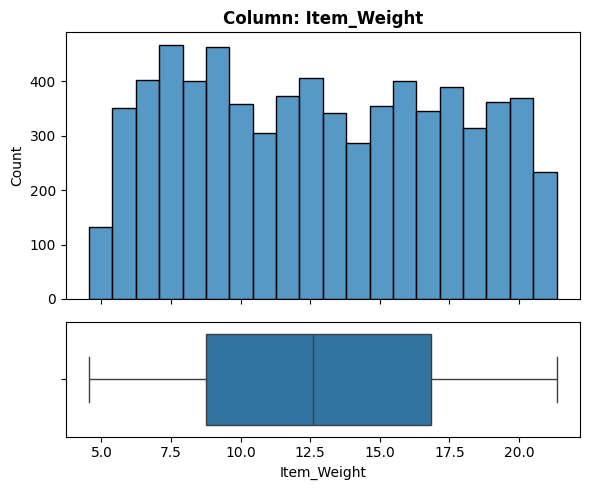

The NaN's count: 1463(17.17%)
Unique Values: 415
- Most common value: 'nan' occurs 1463 times (17.17%)
- Not constant or quasi-constant.


In [56]:
fig , ax =explore_numeric(df,feature )

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
    - Numeric

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
    - 1463 null values (17.17%)
    - Impute with Mean or Median.

3. Is the feature constant or quasi-constant?
    - No.

4. What is the cardinality? Is it high?
    - 415 unique categories.
    -  high

5. Would we know this BEFORE the target is determined?
    - Yes.

6. Is there a business case/understanding reason to exclude based on our business case?
    - No


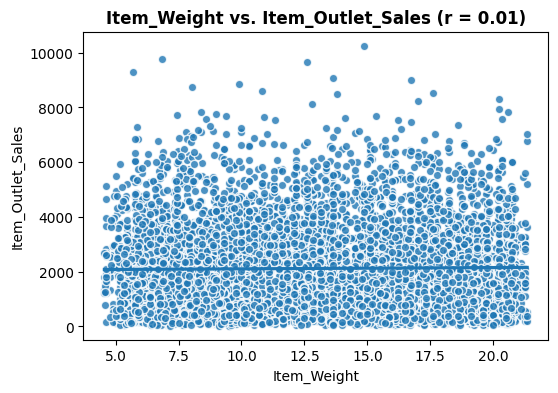

In [57]:
fig,ax=plot_numeric_vs_target(df,feature)

 Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - No, I would expect the weight of the item does not affect to the sales of this item
  - Does this feature appear to be a predictor of the target?
    - No it doesn't


### Feature Name: {Item_Fat_Content}
 - Item_Fat_Content: Type of fat content (Low Fat / Regular)

In [64]:
feature = 'Item_Fat_Content'
df[feature].dtype

dtype('O')

/tmp/ipykernel_1010/1799639814.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


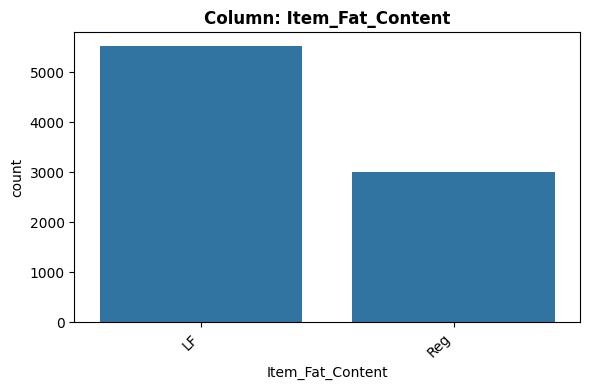

- NaN's Found: 0 (0.0%)
- Unique Values: 2
- Most common value: 'LF' occurs 5517 times (64.73%)
- Not constant or quasi-constant.


(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Column: Item_Fat_Content'}, xlabel='Item_Fat_Content', ylabel='count'>)

In [65]:
explore_categorical(df,feature)

In [66]:
#In fat_content we have inconsistent values
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({'Regular': 'Reg'
,'reg':'Reg'
,'low fat':'LF'
,'Low Fat':'LF'
})

/tmp/ipykernel_1010/1799639814.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


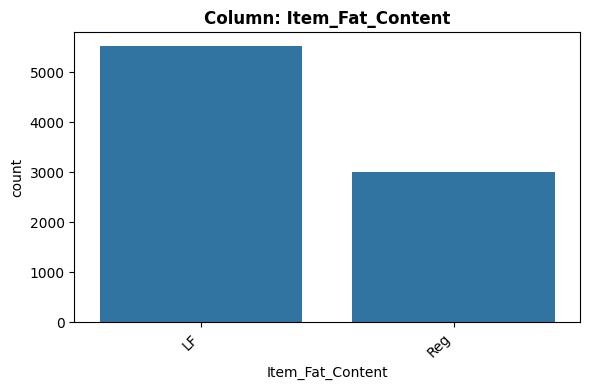

- NaN's Found: 0 (0.0%)
- Unique Values: 2
- Most common value: 'LF' occurs 5517 times (64.73%)
- Not constant or quasi-constant.


(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Column: Item_Fat_Content'}, xlabel='Item_Fat_Content', ylabel='count'>)

In [67]:
explore_categorical(df,feature)

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
    - Categorical(nominal)

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
    - There is no missing values

3. Is the feature constant or quasi-constant?
    - No.

4. What is the cardinality? Is it high?
    - 2 (Low)
    

5. Would we know this BEFORE the target is determined?
    - Yes

6. Is there a business case/understanding reason to exclude based on our business case?
    - Yes

/tmp/ipykernel_1010/2742511303.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


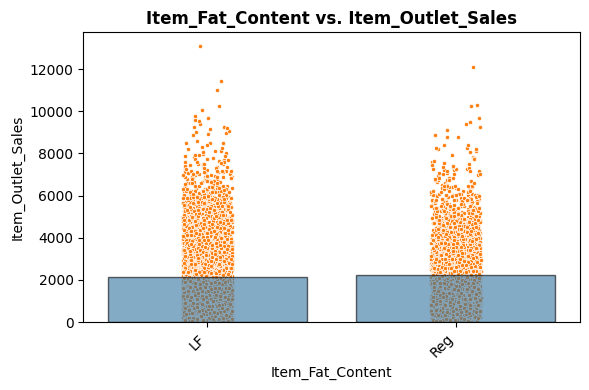

In [69]:
categorical_vs_target(df, feature);

 Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - No, I would expect the LF has higher sales than Reg
  - Does this feature appear to be a predictor of the target?
    - Weak predictor

#### Handle Missing Data

In [ ]:
#Fill the missing value in Item_Weight by mean
#df['Item_Weight'] = df['Item_Weight'].fillna(df['Item_Weight'].mean())

In [ ]:
#Fill the missing value in Outlet_Size by'MISSING'
#df['Outlet_Size'] = df['Outlet_Size'].fillna('MISSING')

###Duplicated Data
Checking for duplicated data:

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df[df.duplicated()]
#NO DUPLICATES

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales


###Rename Columns

In [ ]:
rename = {    'Item_Identifier': 'item_id',
    'Item_Weight': 'weight',
    'Item_Fat_Content': 'fat_content',
    'Item_Visibility': 'visibility',
    'Item_Type': 'item_type',
    'Item_MRP': 'price',
    'Outlet_Identifier': 'outlet_id',
    'Outlet_Establishment_Year': 'est_year',
    'Outlet_Size': 'outlet_size',
    'Outlet_Location_Type': 'location_type',
    'Outlet_Type': 'outlet_type',
    'Item_Outlet_Sales': 'sales'

}

In [ ]:
df=df.rename(rename, axis =1)
df.head()

,item_id,weight,fat_content,visibility,item_type,price,outlet_id,est_year,outlet_size,location_type,outlet_type,sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,MISSING,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


###Checking and Fixing Consistency

In [ ]:
obj_column = df.select_dtypes(include='object')
obj_column.head()

,item_id,fat_content,item_type,outlet_id,outlet_size,location_type,outlet_type
0,FDA15,Low Fat,Dairy,OUT049,Medium,Tier 1,Supermarket Type1
1,DRC01,Regular,Soft Drinks,OUT018,Medium,Tier 3,Supermarket Type2
2,FDN15,Low Fat,Meat,OUT049,Medium,Tier 1,Supermarket Type1
3,FDX07,Regular,Fruits and Vegetables,OUT010,MISSING,Tier 3,Grocery Store
4,NCD19,Low Fat,Household,OUT013,High,Tier 3,Supermarket Type1


In [ ]:
for col in obj_column:
  print(df[col].value_counts())
  print('-----------')

item_id
FDW13    10
FDG33    10
FDX31     9
FDT07     9
NCY18     9
         ..
FDO33     1
FDK57     1
FDT35     1
FDN52     1
FDE52     1
Name: count, Length: 1559, dtype: int64
-----------
fat_content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64
-----------
item_type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64
-----------
outlet_id
OUT027    935
OUT013    932
OUT035    930
OUT049    930
OUT046    930
OUT045    929
OUT018    928
OUT017    926
OUT010    555
OUT019    528


In [ ]:
#In fat_content we have inconsistent values
df['fat_content'] = df['fat_content'].replace({'Regular': 'Reg'
,'reg':'Reg'
,'low fat':'LF'
,'Low Fat':'LF'
})

In [ ]:
df['fat_content'].value_counts()

,count
fat_content,
LF,5517
Reg,3006


###  For any numerical columns, obtain the summary statistics of each (min, max, mean).

In [ ]:
num_col = df.select_dtypes('number')
num_col.head()

,weight,visibility,price,est_year,sales
0,9.30,0.016047,249.8092,1999,3735.1380
1,5.92,0.019278,48.2692,2009,443.4228
2,17.50,0.016760,141.6180,1999,2097.2700
3,19.20,0.000000,182.0950,1998,732.3800
4,8.93,0.000000,53.8614,1987,994.7052


In [ ]:
num_col.describe()

,weight,visibility,price,est_year,sales
count,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.226124,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,9.310000,0.026989,93.826500,1987.000000,834.247400
50%,12.857645,0.053931,143.012800,1999.000000,1794.331000
75%,16.000000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


## **Data Visualization**

In [ ]:
df.head()

,item_id,weight,fat_content,visibility,item_type,price,outlet_id,est_year,outlet_size,location_type,outlet_type,sales
0,FDA15,9.30,LF,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Reg,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,LF,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Reg,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,MISSING,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,LF,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


### Univeriate Visualization

#### Visualize a nemeric column

<Axes: xlabel='sales', ylabel='Count'>

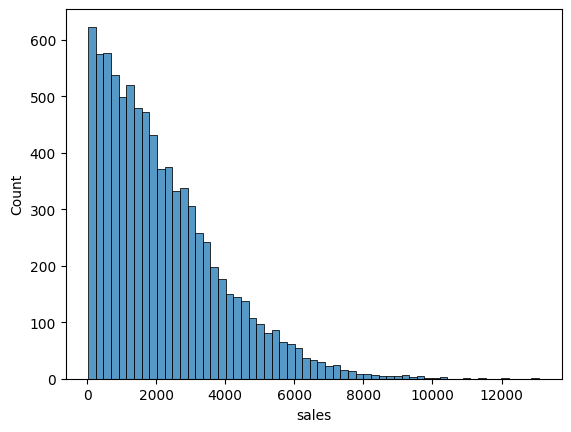

In [ ]:
sns.histplot(data=df , x='sales')

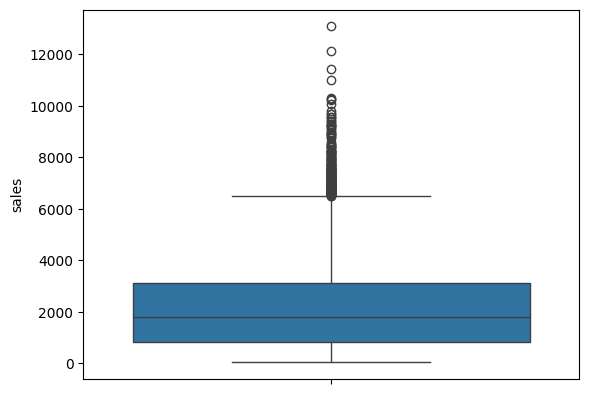

In [ ]:
sns.boxplot(data=df , y='sales');

<Axes: ylabel='price'>

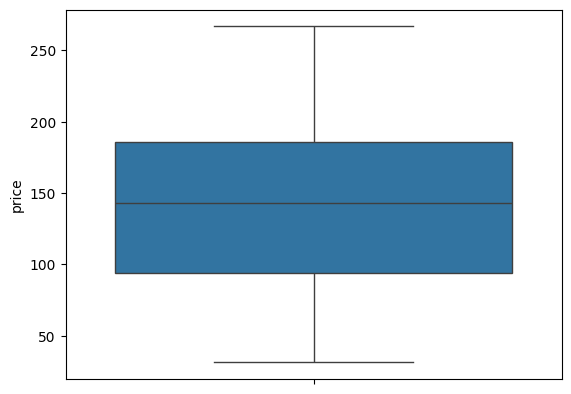

In [ ]:
sns.boxplot(data=df, y='price')

/tmp/ipykernel_480/1677831587.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right");


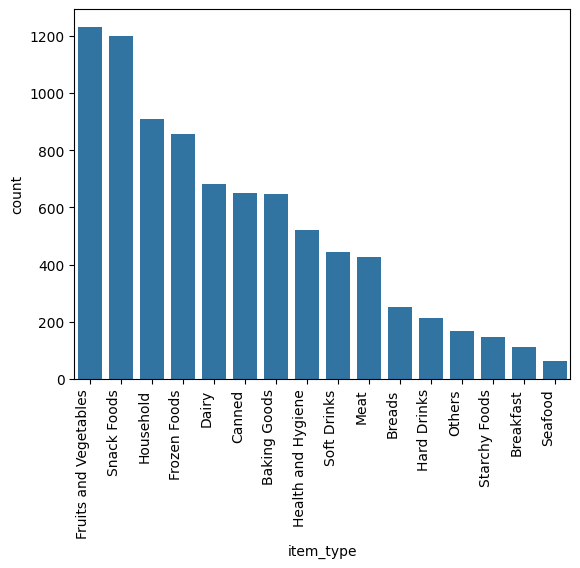

In [ ]:
val_counts=df['item_type'].value_counts()
ax = sns.countplot(data=df, x='item_type', order=val_counts.index);
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right");


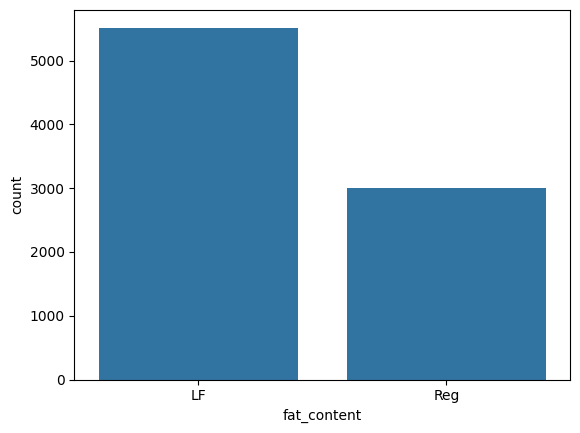

In [ ]:
sns.countplot(data=df , x='fat_content');

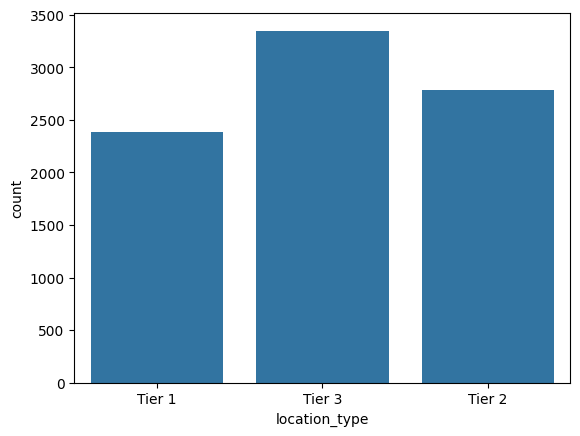

In [ ]:
sns.countplot(data=df , x='location_type');

/tmp/ipykernel_480/3131630443.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right");


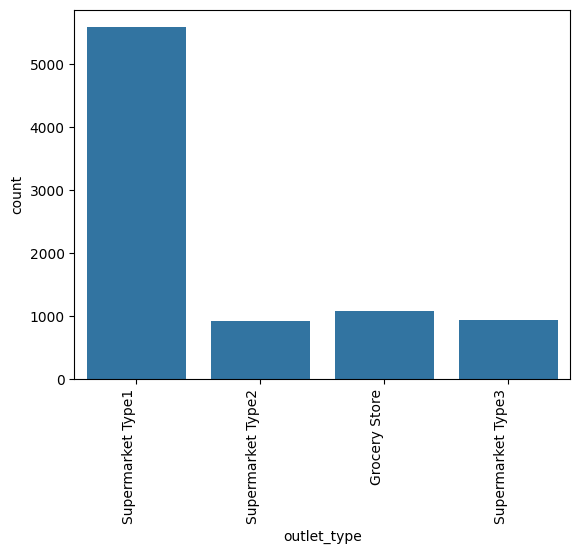

In [ ]:
ax = sns.countplot(data=df , x='outlet_type');
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right");

###Multivariate Visualization

/tmp/ipykernel_480/3666270320.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right");


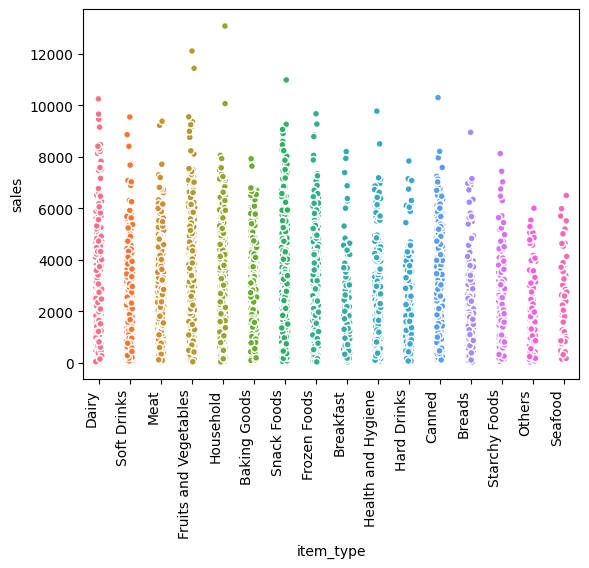

In [ ]:
ax = sns.stripplot(data=df , x='item_type', y='sales', hue='item_type',edgecolor='white' , linewidth=1);
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right");


/tmp/ipykernel_480/634740403.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right");


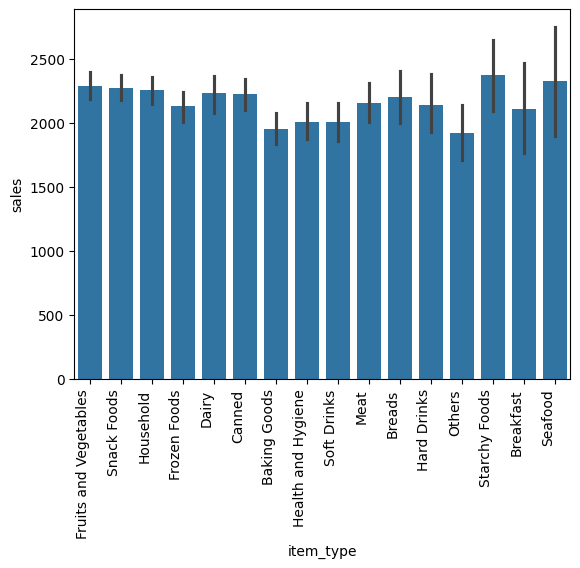

In [ ]:
ax = sns.barplot(data=df , x='item_type', y='sales' , order=val_counts.index);
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right");


Average sales are relatively close across most product categories

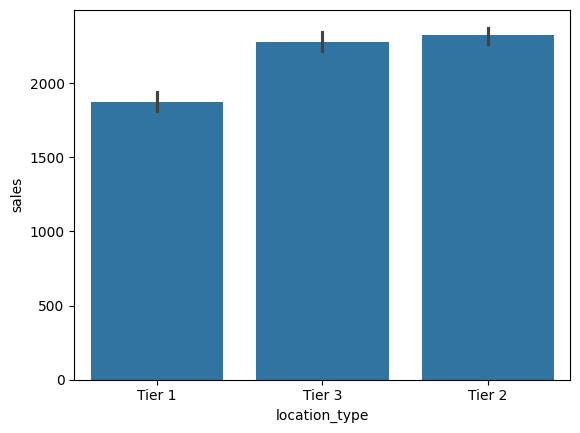

In [ ]:
ax = sns.barplot(data=df , x='location_type', y='sales');

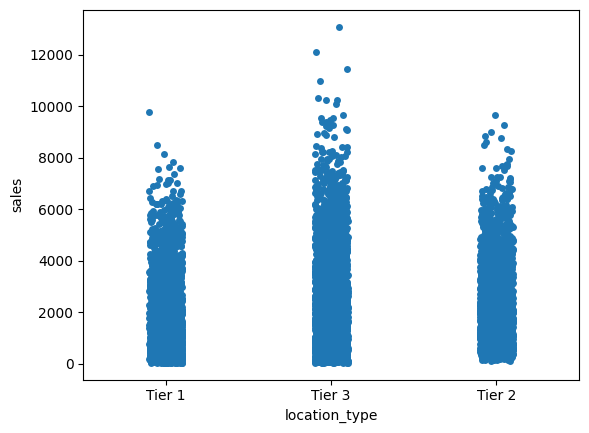

In [ ]:
ax = sns.stripplot(data=df , x='location_type', y='sales');

/tmp/ipykernel_480/2819738577.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right");


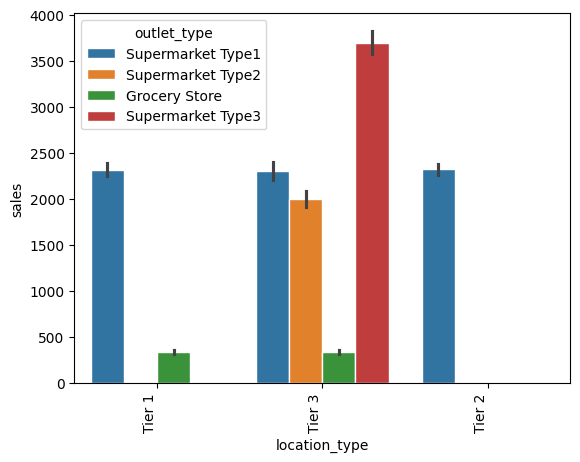

In [ ]:
ax = sns.barplot(data=df, x='location_type' , y='sales' ,hue='outlet_type' , edgecolor='white', linewidth=1)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right");

Supermarket Type3 has the highest sales across all location types, while Grocery Store has the lowest. This suggests that store type has a stronger impact on sales than geographic location.

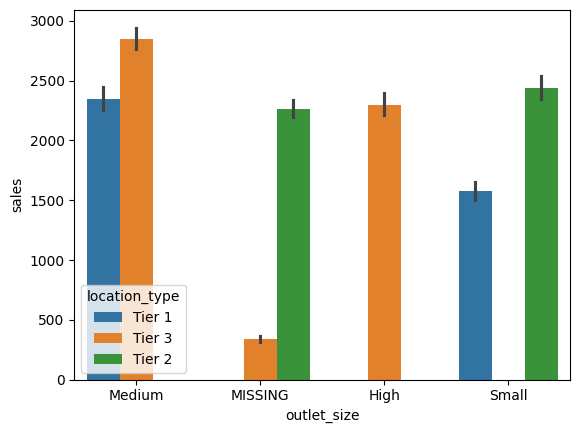

In [ ]:
sns.barplot(data=df , x='outlet_size', y='sales' , hue='location_type');

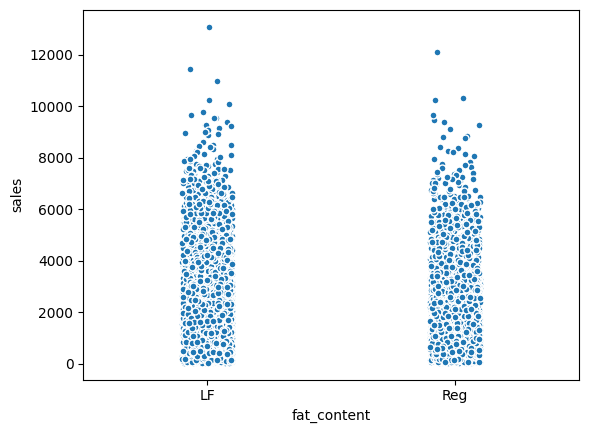

In [ ]:
ax = sns.stripplot(data=df , x='fat_content', y='sales', edgecolor='white', linewidth=1);


<Axes: >

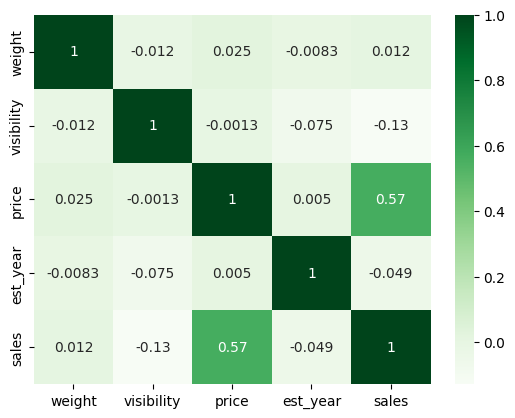

In [ ]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr,cmap='Greens' ,annot=True)

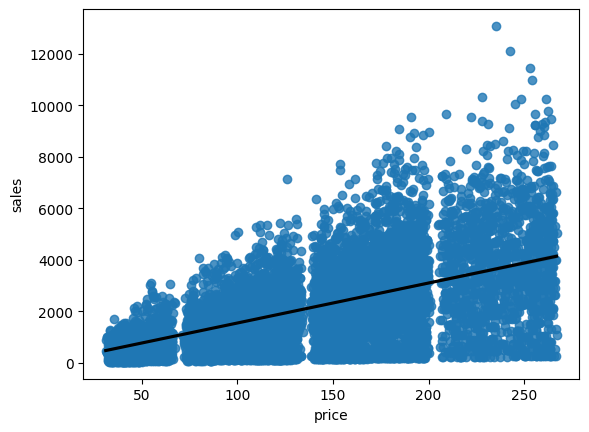

In [ ]:
line_kws = dict(color='black')
ax=sns.regplot(data=df , x='price', y='sales', line_kws=line_kws)

## Feature Inspection